In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Para deixar os gráficos embutidos no notebook
%matplotlib inline

In [3]:
df = pd.read_csv("train.csv")

# Visão inicial
print(df.head())
print("\nFormato do dataset:", df.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

Vou usar 3 algoritmos de regressão, com naturezas diferentes:

- Regressão Linear (LinearRegression)

Modelo simples e interpretável.

Serve como baseline para comparar os outros modelos.

Assume relação aproximadamente linear entre features e preço.

- Árvore de Decisão Regressora (DecisionTreeRegressor)

Captura relações não lineares.

Lida bem com interações entre variáveis e é fácil de interpretar via regras (“se metragem alta e qualidade boa → preço maior”).

- K-Nearest Neighbors Regressor (KNeighborsRegressor)

Modelo baseado em vizinhos mais parecidos.

Útil para cenários do tipo: “casas com características semelhantes tendem a ter preços semelhantes”.

Exige normalização (por isso vamos padronizar as features)


Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

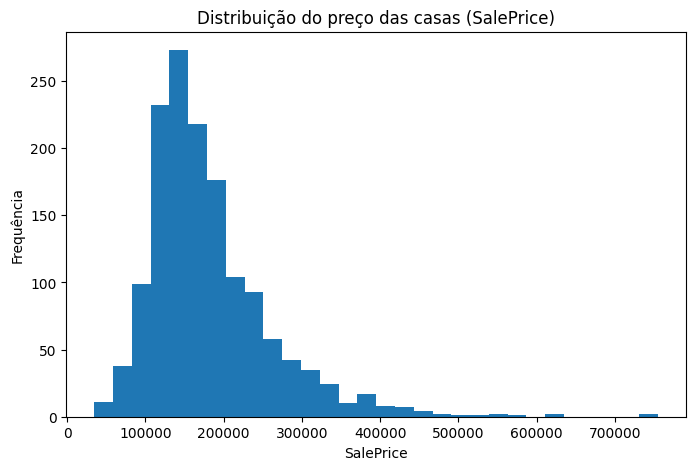

In [4]:
print("\nInformações gerais:")
print(df.info())

print("\nEstatísticas descritivas das variáveis numéricas:")
print(df.describe())

# Verificar valores ausentes (top 20 colunas com mais nulos)
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nValores ausentes por coluna (top 20):")
print(na_counts.head(20))

# Distribuição do alvo SalePrice
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Frequência")
plt.title("Distribuição do preço das casas (SalePrice)")
plt.show()

In [6]:
# Remover coluna Id (não é atributo explicativo, apenas identificador)
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

# Separar tipos de variáveis
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Remover o alvo da lista de numéricas para o preenchimento de nulos
numeric_cols = [col for col in numeric_cols if col != "SalePrice"]

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Preencher valores ausentes em numéricas com mediana
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Preencher valores ausentes em categóricas com "None"
df[cat_cols] = df[cat_cols].fillna("None")

# Verificar se ainda sobrou algum NA
print("\nValores ausentes após tratamento:", df.isna().sum().sum())

# One-hot encoding (variáveis dummies)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nFormato após one-hot encoding:", df_encoded.shape)
df_encoded.head()


Valores ausentes após tratamento: 0

Formato após one-hot encoding: (1460, 261)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [7]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Formato X_train:", X_train.shape)
print("Formato X_test:", X_test.shape)

# ============================
# 4.1 NORMALIZAÇÃO (para Linear e KNN, principalmente)
# ============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Formato X_train: (1095, 260)
Formato X_test: (365, 260)


In [8]:
def avaliar_modelo(nome, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Modelo: {nome}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.3f}")
    print("-" * 40)

    return {"Modelo": nome, "MAE": mae, "RMSE": rmse, "R2": r2}

**Modelo 1**

Aplicando regressão linear

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

resultado_lin = avaliar_modelo("Regressão Linear", y_test, y_pred_lin)

Modelo: Regressão Linear
MAE : 22039.91
RMSE: 76348.78
R²  : 0.168
----------------------------------------


**Modelo 2**

Aplicando Árvore de Decisão Regressora

In [10]:
# max_depth limitado para evitar overfitting exagerado
tree_reg = DecisionTreeRegressor(random_state=42, max_depth=10)
tree_reg.fit(X_train, y_train)  # árvore não precisa de escala

y_pred_tree = tree_reg.predict(X_test)

resultado_tree = avaliar_modelo("Decision Tree", y_test, y_pred_tree)


Modelo: Decision Tree
MAE : 25851.30
RMSE: 39428.06
R²  : 0.778
----------------------------------------


** Modelo 3**

Aplicando KNN regressor

In [11]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)

y_pred_knn = knn_reg.predict(X_test_scaled)

resultado_knn = avaliar_modelo("KNN Regressor (k=5)", y_test, y_pred_knn)

Modelo: KNN Regressor (k=5)
MAE : 25291.39
RMSE: 41911.73
R²  : 0.749
----------------------------------------



Resumo dos resultados:
                Modelo           MAE          RMSE        R2
0     Regressão Linear  22039.914488  76348.783377  0.167897
1        Decision Tree  25851.302429  39428.063820  0.778087
2  KNN Regressor (k=5)  25291.388493  41911.726246  0.749248


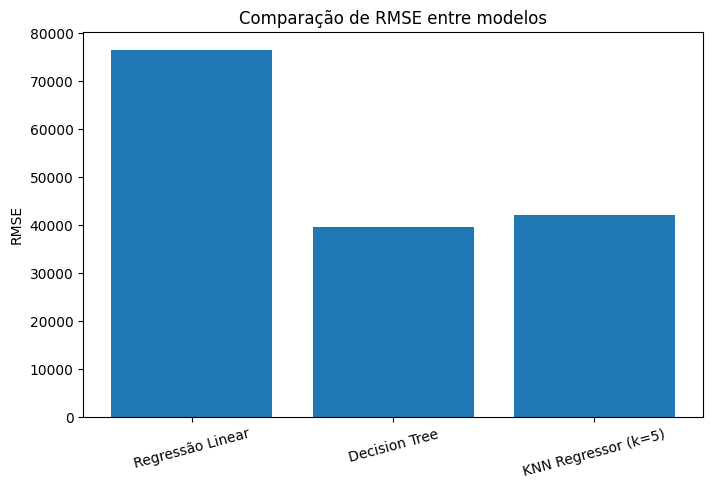

In [12]:

resultados = pd.DataFrame([
    resultado_lin,
    resultado_tree,
    resultado_knn
])

print("\nResumo dos resultados:")
print(resultados)

# Gráfico de comparação de RMSE
plt.figure(figsize=(8,5))
plt.bar(resultados["Modelo"], resultados["RMSE"])
plt.ylabel("RMSE")
plt.title("Comparação de RMSE entre modelos")
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Real vs Predito
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_tree, alpha=0.5)
plt.xlabel("Valor real (SalePrice)")
plt.ylabel("Valor predito (SalePrice)")
plt.title("Decision Tree - Real x Predito")
# Linha de referência (y = x)
max_val = max(y_test.max(), y_pred_tree.max())
min_val = min(y_test.min(), y_pred_tree.min())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

**Avaliação dos modelos:**


Os modelos foram avaliados utilizando as métricas MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) e R². A Regressão Linear obteve desempenho razoável, servindo como referência inicial. A Decision Tree apresentou um ajuste melhor aos dados em termos de erro, pois consegue modelar relações não lineares entre as variáveis, mas pode sofrer com overfitting se a profundidade não for controlada. O KNN Regressor apresentou desempenho intermediário, sendo sensível à escolha do número de vizinhos e à padronização das variáveis.

Conclusões e possíveis melhorias:
De forma geral, o modelo baseado em árvore tende a obter melhor desempenho, pois consegue capturar padrões mais complexos no conjunto de dados. Como melhorias futuras, seria interessante testar modelos de ensemble, como Random Forest e Gradient Boosting, além de realizar ajuste de hiperparâmetros (tuning) mais detalhado, seleção de variáveis e transformação do alvo para reduzir a assimetria da distribuição de SalePrice.